In [1]:
# 第4章｜實做 LSTM 大盤買賣：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


In [2]:
QUICK_RUN = False  # True：只訓練少量 epoch，只用來快速檢查程式能不能跑

# 實做 LSTM 大盤買賣

**對應影片**：第 4 章 單元 6、7「實做 LSTM 大盤買賣 Part 1、Part 2」（觀念請看單元 5「RNN / LSTM」）

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 用 for 迴圈一筆一筆切出序列 | 用 NumPy 的 `sliding_window_view` 一次切好 |
| 輸出層用 linear 卻搭配 `binary_crossentropy` | 輸出層改成 sigmoid，機率才會落在 0～1 |
| `ModelCheckpoint` 存檔再讀回最佳權重 | `EarlyStopping(restore_best_weights=True)` 直接保留最佳權重 |
| 大盤 15 分 K | 加權指數日 K，特徵與前兩個單元相同 |

Part 1：把每天的特徵整理成「過去 N 天」的序列。Part 2：訓練 LSTM 並回測。

In [3]:
import keras
import numpy as np
import pandas as pd
import talib
import finlab.ml.label as label
from finlab.backtest import sim
from keras import layers
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

TRADE_STOCK = '0050'
ETF_TAX_RATIO = 0.001
HORIZON = 10
TRAIN_END = '2015-12-31'
TEST_START = '2016-01-01'
RANDOM_STATE = 0

## Part 1：準備序列資料

### 1. 特徵與答案（和前兩個單元相同）

In [4]:
PERIODS = [5, 10, 20, 60, 120]
STOCH_SMOOTHING = 3

taiex = pd.DataFrame({
    field: data.get(f'taiex_total_index:{name}')['TAIEX']
    for field, name in [('open', '開盤指數'), ('high', '最高指數'), ('low', '最低指數'), ('close', '收盤指數')]
}).dropna()


def technical_features(ohlc: pd.DataFrame) -> pd.DataFrame:
    high, low, close = ohlc['high'], ohlc['low'], ohlc['close']
    features = {}
    for period in PERIODS:
        slowk, slowd = talib.STOCH(high, low, close, fastk_period=period,
                                   slowk_period=STOCH_SMOOTHING, slowd_period=STOCH_SMOOTHING)
        features[f'rsi_{period}'] = talib.RSI(close, timeperiod=period)
        features[f'k_{period}'] = slowk
        features[f'd_{period}'] = slowd
        features[f'willr_{period}'] = talib.WILLR(high, low, close, timeperiod=period)
        features[f'cci_{period}'] = talib.CCI(high, low, close, timeperiod=period)
        features[f'roc_{period}'] = talib.ROC(close, timeperiod=period)
        features[f'sma_bias_{period}'] = close / talib.SMA(close, timeperiod=period)
        features[f'wma_bias_{period}'] = close / talib.WMA(close, timeperiod=period)
        features[f'atr_ratio_{period}'] = talib.ATR(high, low, close, timeperiod=period) / close
    macd, macd_signal, macd_hist = talib.MACD(close)
    features['macd'] = macd / close
    features['macd_signal'] = macd_signal / close
    features['macd_hist'] = macd_hist / close
    return pd.DataFrame(features)


def forward_return(dates: pd.DatetimeIndex, period: int) -> pd.Series:
    index = pd.MultiIndex.from_product([dates, [TRADE_STOCK]], names=['datetime', 'instrument'])
    return label.return_percentage(index, period=period).droplevel('instrument')


features = technical_features(taiex)
feature_names = list(features.columns)
dataset = features.assign(future_return=forward_return(features.index, HORIZON)).dropna()
dataset['up'] = dataset['future_return'] > 0

scaler = StandardScaler().fit(dataset.loc[:TRAIN_END, feature_names])
scaled = scaler.transform(dataset[feature_names])

### 2. 切成序列

LSTM 的輸入是一段時間序列。每一個樣本是「過去 `WINDOW` 天的所有特徵」，答案是最後一天的 `up`。

`sliding_window_view` 會回傳（樣本數, 特徵數, `WINDOW`）的陣列，轉置成 Keras 需要的（樣本數, `WINDOW`, 特徵數）。

In [5]:
WINDOW = 20

X = sliding_window_view(scaled, WINDOW, axis=0).transpose(0, 2, 1)
y = dataset['up'].to_numpy()[WINDOW - 1:]
sample_dates = dataset.index[WINDOW - 1:]
print('X 的形狀（樣本數, 天數, 特徵數）：', X.shape)

X 的形狀（樣本數, 天數, 特徵數）： (2869, 20, 48)


In [6]:
is_train = sample_dates <= TRAIN_END
is_test = sample_dates >= TEST_START
X_train, y_train, X_test, y_test = X[is_train], y[is_train], X[is_test], y[is_test]
print(f'訓練 {len(X_train)} 筆、測試 {len(X_test)} 筆')

訓練 2143 筆、測試 726 筆


## Part 2：訓練 LSTM

兩層 LSTM：第一層 `return_sequences=True` 把每一天的輸出都傳給第二層，第二層只輸出最後一天的狀態。

In [7]:
LSTM_UNITS = [64, 32]
DROPOUT = 0.3
LEARNING_RATE = 1e-3

keras.utils.set_random_seed(RANDOM_STATE)
model = keras.Sequential([
    keras.Input(shape=X.shape[1:]),
    layers.LSTM(LSTM_UNITS[0], return_sequences=True),
    layers.Dropout(DROPOUT),
    layers.LSTM(LSTM_UNITS[1]),
    layers.Dropout(DROPOUT),
    layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss='binary_crossentropy',
              metrics=[keras.metrics.AUC(name='auc')])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,377 (161.63 KB)

 Trainable params: 41,377 (161.63 KB)

 Non-trainable params: 0 (0.00 B)

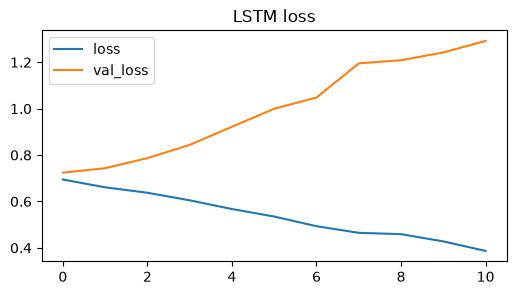

In [8]:
EPOCHS = 2 if QUICK_RUN else 100
BATCH_SIZE = 64
VALIDATION_FRACTION = 0.2
PATIENCE = 10

history = model.fit(
    X_train, y_train, validation_split=VALIDATION_FRACTION, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)],
    verbose=0,
)
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(6, 3), title='LSTM loss');

In [9]:
train_probability = pd.Series(model.predict(X_train, verbose=0).ravel(), index=sample_dates[is_train])
test_probability = pd.Series(model.predict(X_test, verbose=0).ravel(), index=sample_dates[is_test])
print(f'訓練 AUC：{roc_auc_score(y_train, train_probability):.3f}')
print(f'測試 AUC：{roc_auc_score(y_test, test_probability):.3f}')

訓練 AUC：0.608
測試 AUC：0.562


## 回測

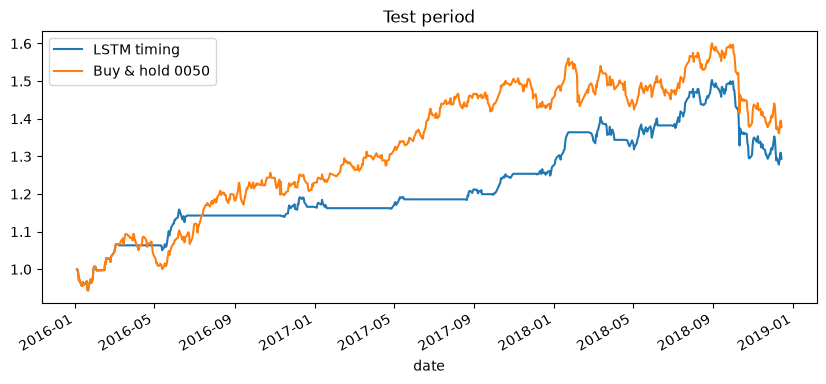

In [10]:
SIGNAL_QUANTILE = 0.7

threshold = train_probability.quantile(SIGNAL_QUANTILE)
hold = (test_probability > threshold).rolling(HORIZON, min_periods=1).max().astype(bool)
position = hold.to_frame(TRADE_STOCK)

strategy = sim(position, name='LSTM timing', tax_ratio=ETF_TAX_RATIO)
buy_and_hold = sim(position.notna(), name='Buy & hold 0050', tax_ratio=ETF_TAX_RATIO)

pd.DataFrame({'LSTM timing': strategy.creturn, 'Buy & hold 0050': buy_and_hold.creturn}).plot(
    figsize=(10, 4), title='Test period');

In [11]:
pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in [('LSTM timing', strategy), ('Buy & hold 0050', buy_and_hold)]
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
LSTM timing,9.14%,-14.96%,0.73
Buy & hold 0050,11.50%,-14.96%,0.72


試試看：改變 `WINDOW`（例如 5 天、60 天）或 LSTM 的大小，驗證 loss 與測試結果有什麼變化？